In [80]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

In [81]:
os.chdir('/Users/cherylxiang/Documents/GitHub/demultiplexing-methods/')
print(os.getcwd())

/Users/cherylxiang/Documents/GitHub/demultiplexing-methods


In [82]:
#get all summary csvs
summary_files = glob.glob('results/**/**/summary.csv', recursive=True)
summary_files = list(set(summary_files))

print(summary_files)

['results/gmmdemux/dataset_2/summary.csv', 'results/demuxmix/dataset_1/summary.csv', 'results/demuxmixnaive/dataset_1/summary.csv', 'results/demuxmixnaive/dataset_2/summary.csv', 'results/hasheddrops/dataset_2/summary.csv', 'results/bffcluster/dataset_2/summary.csv', 'results/htodemux/dataset_2/summary.csv', 'results/hashsolo/dataset_1/summary.csv', 'results/htodemux/dataset_1/summary.csv', 'results/hashsolo/dataset_2/summary.csv', 'results/hasheddrops/dataset_1/summary.csv', 'results/bffcluster/dataset_1/summary.csv', 'results/demultiplex/dataset_2/summary.csv', 'results/demultiplex2/dataset_1/summary.csv', 'results/gmmdemux/dataset_1/summary.csv', 'results/demultiplex2/dataset_2/summary.csv', 'results/bffraw/dataset_1/summary.csv', 'results/demultiplex/dataset_1/summary.csv', 'results/demuxmix/dataset_2/summary.csv']


In [83]:
#read and combine
all_results = pd.concat([pd.read_csv(f) for f in summary_files], ignore_index=True)

#save combined dataframe
all_results.to_csv('results/all_results.csv', index=False)

all_results

,classification,n,dataset,method
0,multiplet,4915,dataset_2,gmmdemux
1,negative,210,dataset_2,gmmdemux
2,singlet,34,dataset_2,gmmdemux
3,total,5159,dataset_2,gmmdemux
4,multiplet,351,dataset_1,demuxmix
...,...,...,...,...
69,total,5159,dataset_1,demultiplex
70,multiplet,664,dataset_2,demuxmix
71,negative,1421,dataset_2,demuxmix
72,singlet,2565,dataset_2,demuxmix


In [84]:
errors_file = 'results/errors.csv'
if os.path.exists(errors_file):
    errors = pd.read_csv(errors_file)
else:
    errors = pd.DataFrame(columns=['dataset', 'method', 'error'])

errors

,dataset,method,error
0,dataset_2,bff_raw,High doublet rate (95%) exceeded filter thresh...


In [85]:
plot_data = all_results[all_results['classification'] != 'total'].copy()

datasets = plot_data['dataset'].unique()

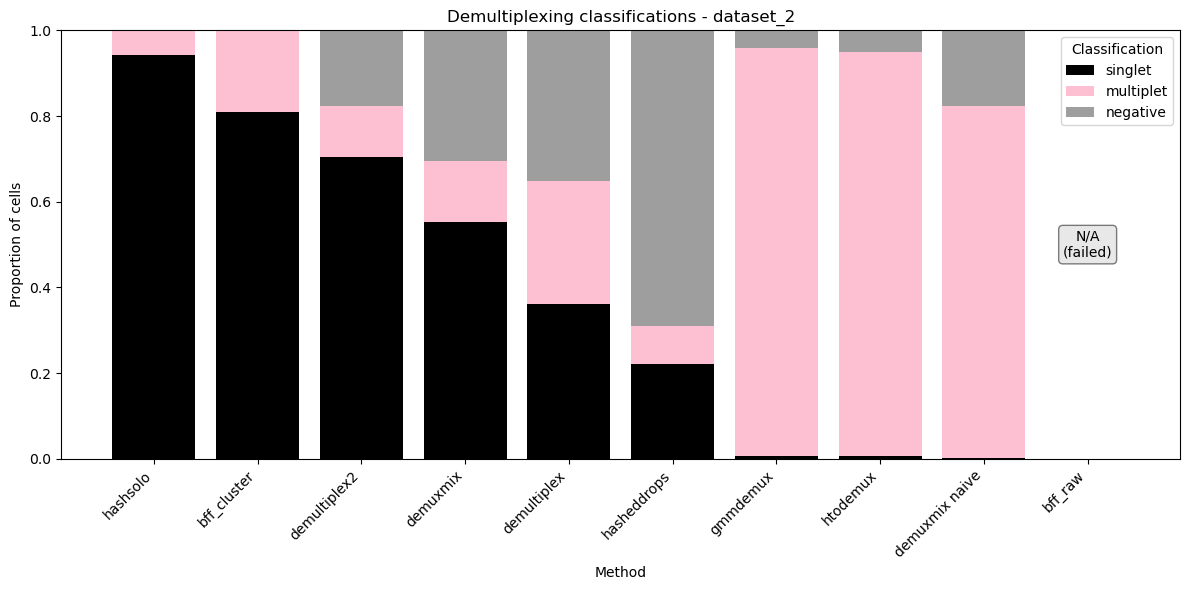

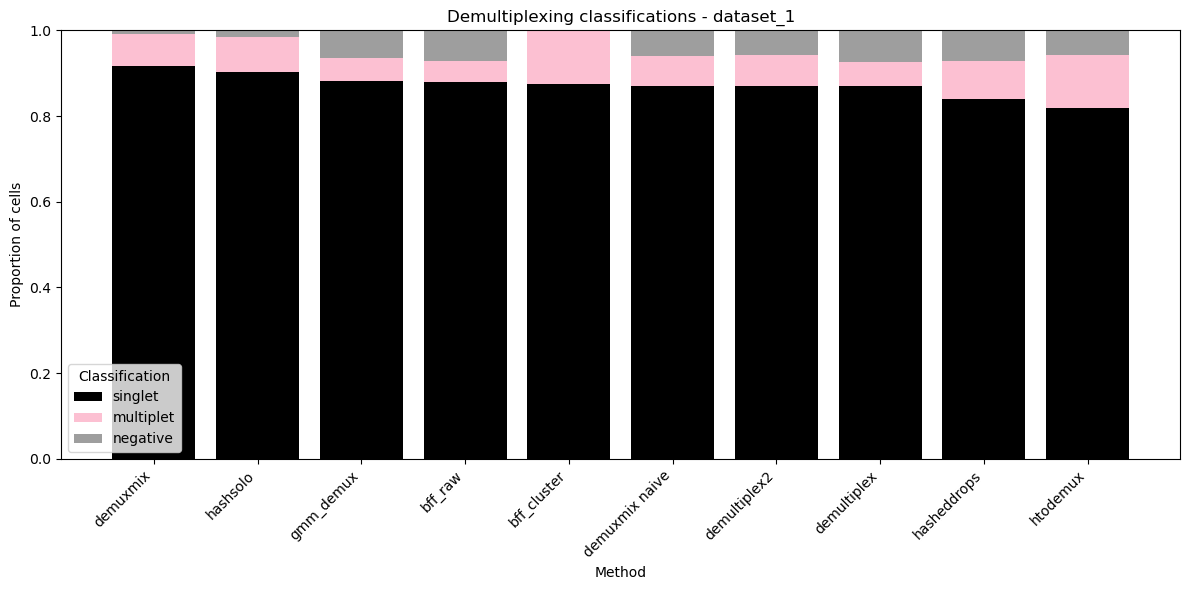

In [86]:
colors = {
    'singlet':  '#000000', 
    'multiplet':  '#fcc0d2', 
    'negative': '#9E9E9E'
}

for dataset in datasets:
    dataset_data = plot_data[plot_data['dataset'] == dataset].copy()
    dataset_data['proportion'] = dataset_data.groupby('method')['n'].transform(lambda x: x / x.sum())

    sort_order = dataset_data[dataset_data['classification'] == 'singlet'][['method', 'proportion']].rename(columns={'proportion': 'singlet_prop'})
    sort_order = sort_order.merge(
        dataset_data[dataset_data['classification'] == 'negative'][['method', 'proportion']].rename(columns={'proportion': 'negative_prop'}),
        on='method',
        how='left'
    ).fillna(0)

    # sort by singlet desc then doublet desc
    sort_order = sort_order.sort_values(['singlet_prop', 'negative_prop'], ascending=[False, True])
    method_order = sort_order['method'].tolist()

    pivot = dataset_data.pivot_table(
        index='method',
        columns='classification',
        values='proportion',
        fill_value=0
    )

    # apply order to pivot
    pivot = pivot.loc[method_order]

    errors_for_dataset = errors[errors['dataset'] == dataset]
    for _, row in errors_for_dataset.iterrows():
        if row['method'] not in pivot.index:
            pivot.loc[row['method']] = 0

    col_order = [c for c in ['singlet', 'multiplet', 'negative'] if c in pivot.columns]
    pivot = pivot[col_order]

    fig, ax = plt.subplots(figsize=(12, 6))
    bottom = pd.Series([0] * len(pivot), index=pivot.index)

    for classification in col_order:
        bars = ax.bar(pivot.index, pivot[classification],
                  bottom=bottom,
                  label=classification,
                  color=colors[classification])
        bottom += pivot[classification]

    # add failed methods note
    dataset_errors = errors[errors['dataset'] == dataset]
    for _, row in errors_for_dataset.iterrows():
        method_idx = list(pivot.index).index(row['method'])
        ax.text(method_idx, 0.5, 'N/A\n(failed)', 
            ha='center', va='center',
            fontsize=10, color='black',
            bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.5))

    ax.set_xlabel('Method')
    ax.set_ylabel('Proportion of cells')
    ax.set_title(f'Demultiplexing classifications - {dataset}')
    ax.set_ylim(0, 1)
    ax.legend(title='Classification')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

    os.makedirs(f'analysis/figures/{dataset}', exist_ok=True)
    plt.savefig(f'analysis/figures/{dataset}/stacked_bar.pdf')
    plt.show()